# CODaN Feature Extraction
This notebook converts CODaN CSV image indexes into HSV value features. It runs `process_codan_csv` on the train, test, and val splits.

## Imports

In [1]:
from pathlib import Path
import pandas as pd
import cv2
import inspect

import matplotlib.pyplot as plt
import seaborn as sns

## process_codan_csv

In [2]:
def process_codan_csv(data_dir, csv_path, out_file=None):
    func_name = inspect.currentframe().f_code.co_name
    print( f"** In {func_name}, tracing arguments..." )
    for name, value in locals().items():
        print( f"{name}: {value}" )
    print( "Tracing done." )      
    
    csv_path = Path(csv_path)
    repo_root = Path(data_dir).resolve()
    if not csv_path.is_absolute():
        csv_path = repo_root / csv_path
    print(f"CSV path: {csv_path}")

    if not csv_path.exists():
        raise FileNotFoundError(f'Index CSV not found: {csv_path}')

    if out_file:
        out_path = Path(out_file)
    else:
        out_path = csv_path.parent / 'images_features_and_labels.csv'
    print(f"Output path: {out_path}")
    out_path.parent.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(csv_path, header=0)
    if df.shape[1] < 2:
        raise ValueError('Input CSV must have at least two columns: filename, label')
    if 'filename' in df.columns and 'class' in df.columns:
        df = df.rename(columns={'class': 'label'})[['filename', 'label']]
    else:
        df = df.iloc[:, :2]
        df.columns = ['filename', 'label']
    print(f"CSV head: {df.head(2)}")
    print(f"CSV tail: {df.tail(2)}")    

    base_data_dir = repo_root
    rows = []
    missing = 0
    for idx, row in df.iterrows():
        fname = str(row['filename'])
        label = row['label']
        fpath = Path(fname)
        candidates = []
        if fpath.is_absolute():
            candidates.append(fpath)
        else:
            candidates.append(csv_path.parent / fpath)
            candidates.append(base_data_dir / 'train' / fpath)
            candidates.append(base_data_dir / 'test' / fpath)
            candidates.append(base_data_dir / 'val' / fpath)
            candidates.append(base_data_dir / fpath)
            for p in base_data_dir.rglob(fpath.name):
                candidates.append(p)

        img_path = None
        for c in candidates:
            if c.exists() and c.is_file():
                img_path = c
                break

        if img_path is None:
            print(f'Warning: image not found for entry {fname} (skipping)')
            missing += 1
            continue
        
        if ( idx<2 ):
            print(f"Processing image {idx}: {img_path}")

        # feature extraction
        img = cv2.imread(str(img_path))
        if img is None:
            print(f'Warning: failed to read image: {img_path} (skipping)')
            missing += 1
            continue
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        avg_v = float(hsv[:, :, 2].mean()) / 255.0
        rows.append((fname, avg_v, int(label)))

    out_df = pd.DataFrame(rows, columns=['filename', 'avg_value', 'label'])
    out_df.to_csv(out_path, index=False)
    print(f'Wrote {len(out_df)} rows to {out_path} (skipped {missing} missing)')
    return out_df

## process data split

In [ ]:
def process_data_split(data_dir='../../data/CODaN', section='train'):
    func_name = inspect.currentframe().f_code.co_name
    print( f"** In {func_name}, tracing arguments..." )
    for name, value in locals().items():
        print( f"{name}: {value}" )
    print( "Tracing done." )  

    csv_path = data_dir + "/" + section + "/" + f'{section}_images_and_labels.csv'
    out_path = data_dir + "/" + section + "/" + f'{section}_images_features_and_labels.csv'
    results = []
    results.append( process_codan_csv(data_dir, csv_path, out_file=out_path) )
    
    return pd.concat(results, ignore_index=True)

## Run on train/test/val splits

In [4]:
results =  process_data_split(data_dir='../../data/CODaN', section="train")
results.head(2)

results =  process_data_split(data_dir='../../data/CODaN', section="val")
results.head(2)

results =  process_data_split(data_dir='../../data/CODaN', section="test")
results.head(2)

** In process_data_split, tracing arguments...
data_dir: ../../data/CODaN
section: train
func_name: process_data_split
Tracing done.
** In process_codan_csv, tracing arguments...
data_dir: ../../data/CODaN
csv_path: ../../data/CODaN/train/train_images_and_labels.csv
out_file: ../../data/CODaN/train/train_image_values.csv
func_name: process_codan_csv
Tracing done.
CSV path: /home/schelian/prjs/python_project_template/data/CODaN/../../data/CODaN/train/train_images_and_labels.csv
Output path: ../../data/CODaN/train/train_image_values.csv
CSV head:                                             filename  label
0    ../../data/CODaN/train/night_Bus_2015_02014.jpg      2
1  ../../data/CODaN/train/night_Motorbike_2015_05...      2
CSV tail:                                              filename  label
78   ../../data/CODaN/train/night_Boat_2015_01307.jpg      2
79  ../../data/CODaN/train/night_Bottle_2015_01475...      2
Processing image 0: /home/schelian/prjs/python_project_template/data/CODaN/.

,filename,avg_value,label
0,../../data/CODaN/test/day_Motorbike_0000003605...,0.465861,1
1,../../data/CODaN/test/night_Boat_2015_00861.jpg,0.135831,2


## Histogram of avg_value by label (train)


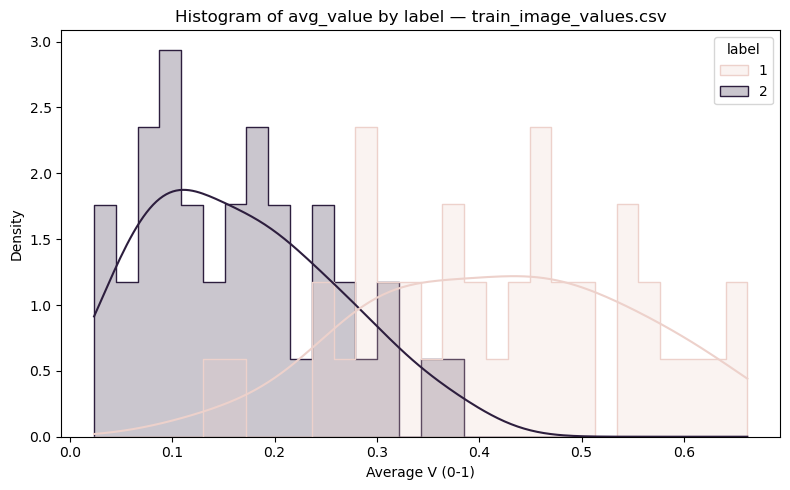

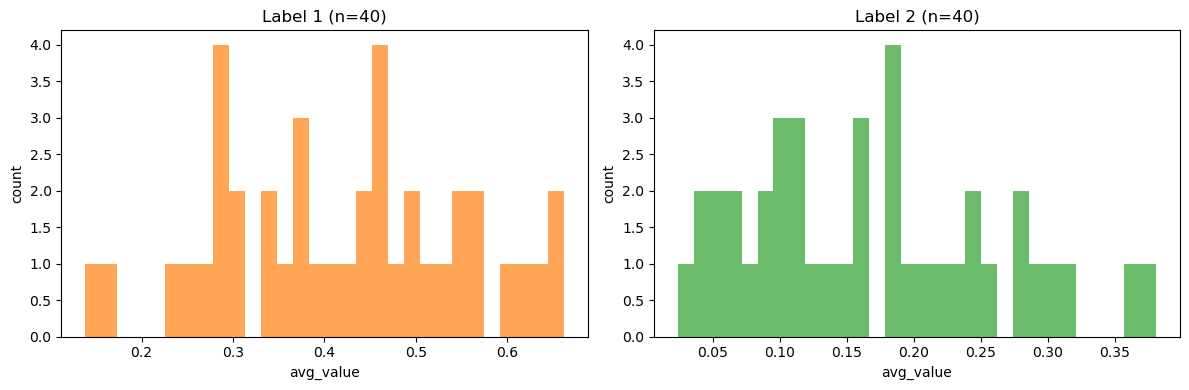

In [5]:
# locate the train image values CSV written earlier
candidates = [Path('../../data/CODaN/train/train_image_values.csv'),
]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(f'Could not find train image values CSV; checked: {candidates}')

df = pd.read_csv(csv_path)
df['avg_value'] = pd.to_numeric(df['avg_value'], errors='coerce')

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='avg_value', hue='label', bins=30, stat='density', kde=True, element='step')
plt.xlabel('Average V (0-1)')
plt.title(f'Histogram of avg_value by label — {csv_path.name}')
plt.tight_layout()
plt.show()

# side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12,4))
labels = sorted(df['label'].dropna().unique())
for ax, lab in zip(axes, labels):
    subset = df[df['label']==lab]
    ax.hist(subset['avg_value'].dropna(), bins=30, color=f'C{int(lab)}', alpha=0.7)
    ax.set_title(f'Label {lab} (n={len(subset)})')
    ax.set_xlabel('avg_value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()
